In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
from Bio.PDB import *
from scipy.spatial import cKDTree, ConvexHull

In [2]:
p = PDBParser()

def get_points(pdb_path):
    structure = p.get_structure('input', pdb_path)
    CA_coord = []
    for model in structure:
        for chain in model:
            for residue in chain:
                _vector = residue['CA'].get_vector()
                CA_coord.append([_vector[0], _vector[1], _vector[2]])
    
    points = np.array(CA_coord)
    return points

In [3]:
points = {
    'Z_naive_X': get_points('./Z_naive_X/concat_1735275745875.pdb'),
    'Z_IgDn_X': get_points('./Z_IgDn_X/concat_1735275871942.pdb'),
    'ZF_naive_X': get_points('./ZF_naive_X/concat_1735276762067.pdb'),
    'ZF_IgDn_X': get_points('./ZF_IgDn_X/concat_1735276896226.pdb'),
    'ZM_naive_X': get_points('./ZM_naive_X/concat_1735276909833.pdb'),
    'ZM_IgDn_X': get_points('./ZM_IgDn_X/concat_1735277362861.pdb'),
}

/home/liminghong/mambaforge/envs/turner/lib/python3.8/site-packages/Bio/PDB/Atom.py:232: PDBConstructionWarning: Used element 'C' for Atom (name=CA) with given element ''
  warnings.warn(msg, PDBConstructionWarning)
/home/liminghong/mambaforge/envs/turner/lib/python3.8/site-packages/Bio/PDB/Atom.py:232: PDBConstructionWarning: Used element 'C' for Atom (name=CA) with given element ''
  warnings.warn(msg, PDBConstructionWarning)
/home/liminghong/mambaforge/envs/turner/lib/python3.8/site-packages/Bio/PDB/Atom.py:232: PDBConstructionWarning: Used element 'C' for Atom (name=CA) with given element ''
  warnings.warn(msg, PDBConstructionWarning)
/home/liminghong/mambaforge/envs/turner/lib/python3.8/site-packages/Bio/PDB/Atom.py:232: PDBConstructionWarning: Used element 'C' for Atom (name=CA) with given element ''
  warnings.warn(msg, PDBConstructionWarning)
/home/liminghong/mambaforge/envs/turner/lib/python3.8/site-packages/Bio/PDB/Atom.py:232: PDBConstructionWarning: Used element 'C' for At

In [4]:
volumes, areas = {}, {}
for key, value in points.items():
    _value = ConvexHull(value)
    volumes[key] = _value.volume
    areas[key] = _value.area

average_distances = {}
for key, value in points.items():
    kdtree = cKDTree(value)

    k = 5
    distances, indices = kdtree.query(value, k=k+1)
    average_distance = np.mean(distances[:, 1:])

    average_distances[key] = average_distance

In [5]:
def triangle_area(point1, point2, point3):
    x1, y1, z1 = point1
    x2, y2, z2 = point2
    x3, y3, z3 = point3
    AB = (x2 - x1, y2 - y1, z2 - z1)
    AC = (x3 - x1, y3 - y1, z3 - z1)
    
    cross_product = (
        AB[1] * AC[2] - AB[2] * AC[1],
        AB[2] * AC[0] - AB[0] * AC[2],
        AB[0] * AC[1] - AB[1] * AC[0]
    )

    magnitude = math.sqrt(
        cross_product[0]**2 + cross_product[1]**2 + cross_product[2]**2
    )

    area = 0.5 * magnitude
    return area

def get_xyz(points):
    PAR1 = points[0:5]
    PAR2 = points[-2:]
    Centrosome = points[117:122]
    PAR1 = np.mean(PAR1, axis=0)
    PAR2 = np.mean(PAR2, axis=0)
    Centrosome = np.mean(Centrosome, axis=0)
    return PAR1, PAR2, Centrosome


triangle_areas = {}
for key, value in points.items():
    triangle_areas[key] = triangle_area(*get_xyz(value))

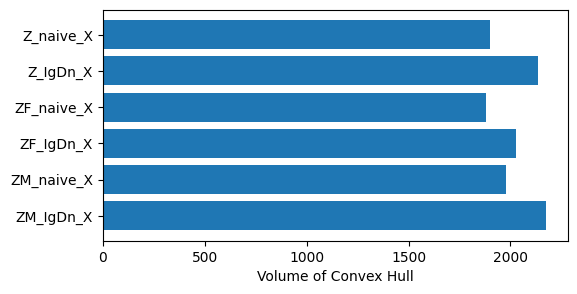

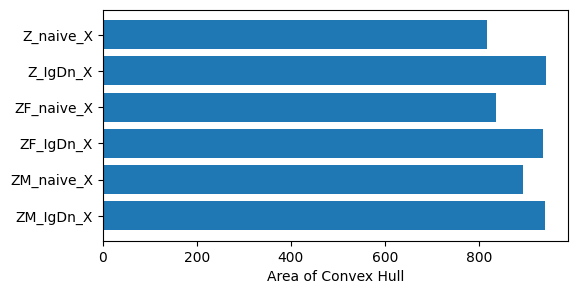

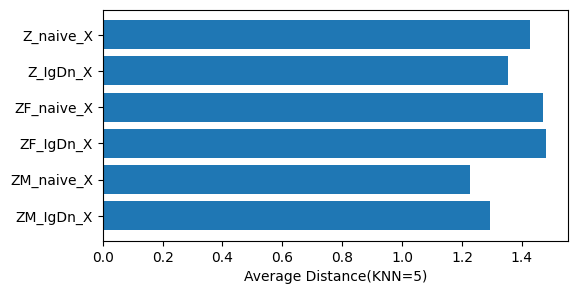

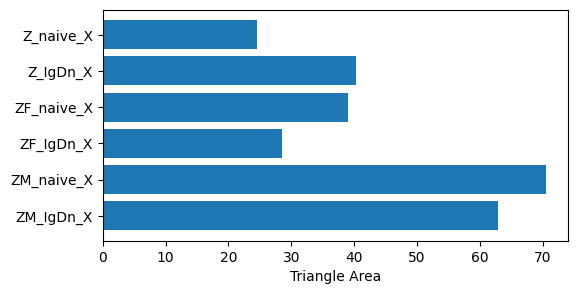

In [6]:
def barplot(data, title):
    plt.figure(figsize=(6, 3))

    x = list(data.keys())
    y = list(data.values())
    plt.barh(x, y)
    plt.gca().invert_yaxis()

    plt.xlabel(title)
    plt.savefig("{}.pdf".format(title), format='pdf', bbox_inches='tight')
    plt.show()

barplot(volumes, 'Volume of Convex Hull')
barplot(areas, 'Area of Convex Hull')
barplot(average_distances, 'Average Distance(KNN=5)')
barplot(triangle_areas, 'Triangle Area')

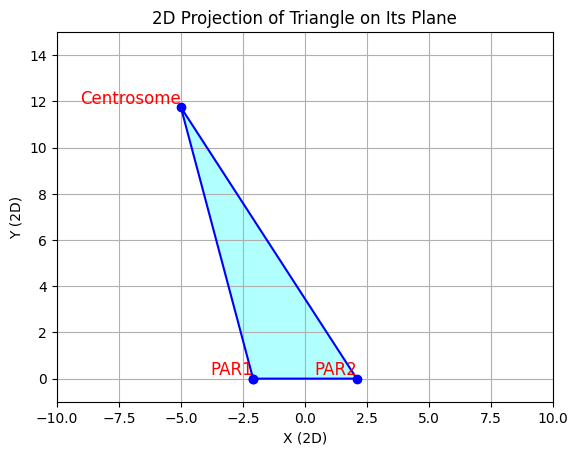

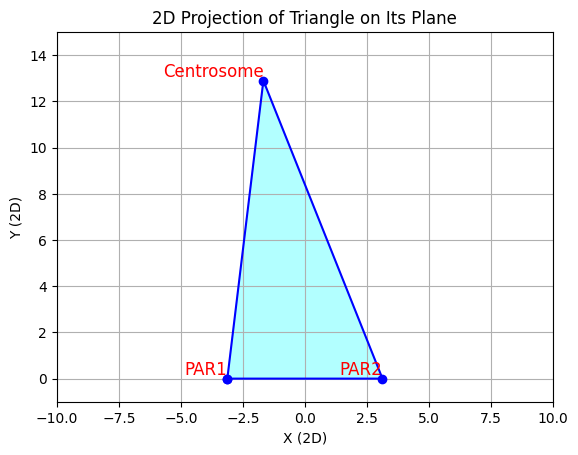

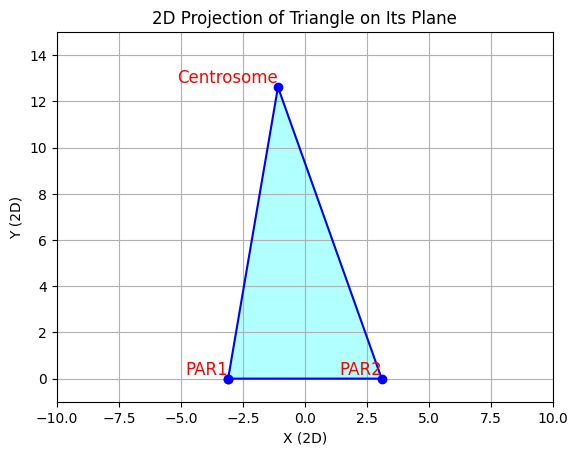

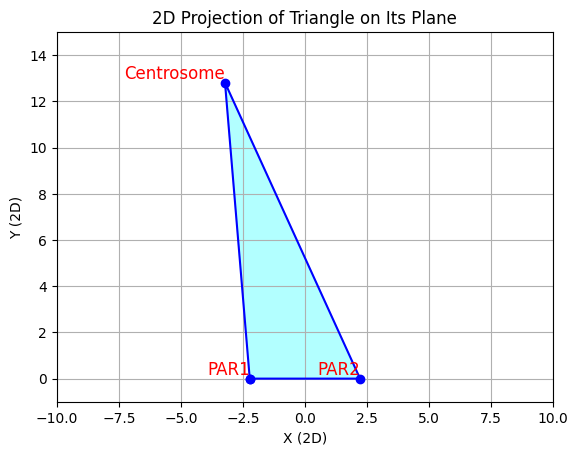

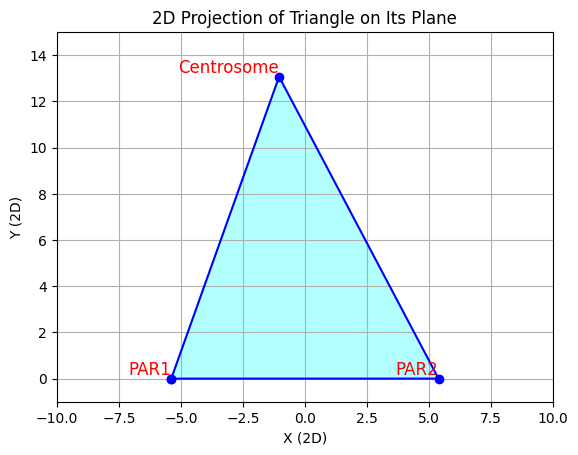

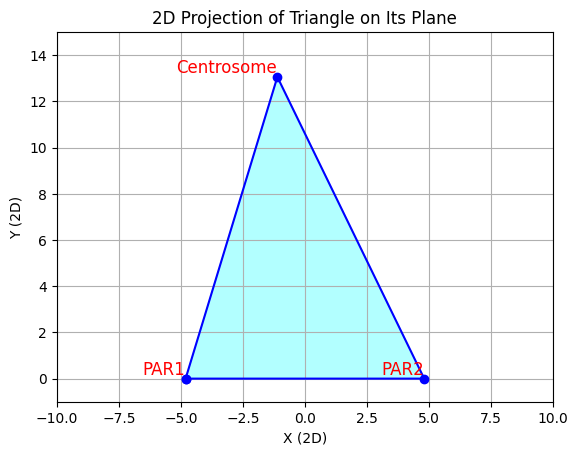

In [7]:
def plot_triangle(p1, p2, p3, file_path=None):
    normal = np.cross(p2 - p1, p3 - p1)
    normal = normal / np.linalg.norm(normal)

    u = p2 - p1
    u = u / np.linalg.norm(u)
    v = np.cross(normal, u)

    projection_matrix = np.array([u, v])
    projected_points = np.dot(projection_matrix, np.concatenate((p1, p2, p3)).reshape((3, 3)).T).T

    projected_points[:, 0] = projected_points[:, 0] - projected_points[:2, 0].mean()
    projected_points[:, 1] = projected_points[:, 1] - projected_points[:, 1].min()

    x_2d, y_2d = projected_points[:, 0], projected_points[:, 1]

    x_2d = np.append(x_2d, x_2d[0])
    y_2d = np.append(y_2d, y_2d[0])

    plt.figure()
    plt.plot(x_2d, y_2d, marker='o', linestyle='-', color='b')
    plt.fill(x_2d, y_2d, alpha=0.3, color='cyan')

    labels = ['PAR1', 'PAR2', 'Centrosome']
    for i, (x, y) in enumerate(projected_points[:, 0:2]):
        plt.text(x, y, labels[i], fontsize=12, ha='right', va='bottom', color='red')

    plt.xlabel('X (2D)')
    plt.ylabel('Y (2D)')
    plt.title('2D Projection of Triangle on Its Plane')
    plt.grid(True)

    plt.xlim(-10, 10)
    plt.ylim(-1, 15)

    if file_path is not None:
        plt.savefig(file_path, format='pdf', bbox_inches='tight')

    plt.show()

plot_triangle(*get_xyz(points['Z_naive_X']), './triangle/Z_naive_X.pdf')
plot_triangle(*get_xyz(points['Z_IgDn_X']), './triangle/Z_IgDn_X.pdf')
plot_triangle(*get_xyz(points['ZF_naive_X']), './triangle/ZF_naive_X.pdf')
plot_triangle(*get_xyz(points['ZF_IgDn_X']), './triangle/ZF_IgDn_X.pdf')
plot_triangle(*get_xyz(points['ZM_naive_X']), './triangle/ZM_naive_X.pdf')
plot_triangle(*get_xyz(points['ZM_IgDn_X']), './triangle/ZM_IgDn_X.pdf')